<a href="https://colab.research.google.com/github/AlexanderOlivera/Analisis-de-algoritmos/blob/main/Divide_and_Conquer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Estrategia de **Divide y Vencerás**
## Merge Sort, Bubble Sort y Binary Search

Este notebook está diseñado para **reforzar el tema de la estrategia de Divide y Vencerás** en la materia de **Diseño y Análisis de Algoritmos**.

## 🎯 Objetivos
Al finalizar este material, deberías poder:

- comprender la idea general de **Divide y Vencerás**;
- identificar qué algoritmos sí siguen esta estrategia y cuáles no;
- analizar recursiones usando el **Método Maestro**;
- comparar experimentalmente el rendimiento de:
  - **Merge Sort**
  - **Bubble Sort**
  - **Binary Search**

---

## 🧠 Idea central de Divide y Vencerás

La estrategia de **Divide y Vencerás** consiste en resolver un problema grande mediante tres pasos:

1. **Dividir** el problema en subproblemas más pequeños.
2. **Vencer** resolviendo recursivamente esos subproblemas.
3. **Combinar** las soluciones parciales para obtener la solución final.

Esta estrategia suele producir algoritmos muy eficientes cuando:
- la división del problema es balanceada,
- el costo de combinar no es demasiado alto,
- y la recurrencia resultante es favorable.


# 1. Bubble Sort: referencia de un algoritmo clásico **no** basado en Divide y Vencerás

Bubble Sort se incluye aquí como punto de comparación.

## ¿Cómo funciona?
Recorre repetidamente el arreglo, comparando pares de elementos adyacentes e intercambiándolos si están en el orden incorrecto. En cada pasada, los elementos grandes “suben” hacia el final.

## Idea de análisis
Bubble Sort no divide el problema en subproblemas independientes.  
Su estructura se basa en ciclos anidados y comparaciones repetidas.


In [ ]:
def bubble_sort(arr):
    a = arr.copy()
    n = len(a)
    for i in range(n - 1):
        swapped = False
        for j in range(n - i - 1):
            if a[j] > a[j + 1]:
                a[j], a[j + 1] = a[j + 1], a[j]
                swapped = True
        if not swapped:
            break
    return a


## Análisis teórico breve
Si el arreglo tiene tamaño `n`, en el peor caso se realizan múltiples pasadas y, dentro de cada una, múltiples comparaciones.

Esto lleva a una suma del tipo:

\[
(n-1) + (n-2) + \cdots + 1
\]

que corresponde a un crecimiento cuadrático.

> Bubble Sort es útil aquí porque nos permite contrastar un algoritmo iterativo clásico contra uno de Divide y Vencerás.


# 2. Merge Sort: ejemplo clásico de Divide y Vencerás

## ¿Cómo funciona?
Merge Sort aplica perfectamente la estrategia:

1. **Divide** el arreglo en dos mitades.
2. **Vence** ordenando recursivamente cada mitad.
3. **Combina** ambas mitades ya ordenadas en una sola lista ordenada.

La clave de su eficiencia está en que:
- divide el problema en dos partes balanceadas;
- y la combinación puede hacerse en tiempo lineal.


In [ ]:
def merge(left, right):
    result = []
    i = 0
    j = 0

    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1

    result.extend(left[i:])
    result.extend(right[j:])
    return result

def merge_sort(arr):
    if len(arr) <= 1:
        return arr.copy()

    mid = len(arr) // 2
    left = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])
    return merge(left, right)


## 📐 Recurrencia de Merge Sort

Si `T(n)` representa el tiempo de ejecución de Merge Sort, entonces:

\[
T(n) = 2T\left(\frac{n}{2}\right) + cn
\]

porque:
- se resuelven **2 subproblemas** de tamaño `n/2`,
- y combinar ambas mitades cuesta aproximadamente `cn`.

---

## Aplicación del Método Maestro

La forma general del Método Maestro es:

\[
T(n)=aT\left(\frac{n}{b}\right)+f(n)
\]

En Merge Sort:
- `a = 2`
- `b = 2`
- `f(n) = cn`

Calculamos:

\[
n^{\log_b a} = n^{\log_2 2} = n
\]

Como:

\[
f(n) = \Theta(n)
\]

entonces estamos en el **Caso 2** del Método Maestro:

\[
T(n) = \Theta(n \log n)
\]

✅ Conclusión: **Merge Sort tiene complejidad temporal Θ(n log n)**.


# 3. Binary Search: Divide y Vencerás para búsqueda

## ¿Cómo funciona?
Binary Search trabaja sobre un arreglo **ordenado**.

En cada paso:
1. revisa el elemento central;
2. si ese elemento es el buscado, termina;
3. si el valor buscado es menor, continúa en la mitad izquierda;
4. si es mayor, continúa en la mitad derecha.

Es decir, en cada paso **reduce el tamaño del problema a la mitad**.


In [ ]:
def binary_search(arr, target):
    low = 0
    high = len(arr) - 1

    while low <= high:
        mid = (low + high) // 2
        if arr[mid] == target:
            return mid
        elif target < arr[mid]:
            high = mid - 1
        else:
            low = mid + 1
    return -1

def binary_search_recursive(arr, target, low=0, high=None):
    if high is None:
        high = len(arr) - 1

    if low > high:
        return -1

    mid = (low + high) // 2
    if arr[mid] == target:
        return mid
    elif target < arr[mid]:
        return binary_search_recursive(arr, target, low, mid - 1)
    else:
        return binary_search_recursive(arr, target, mid + 1, high)


## 📐 Recurrencia de Binary Search

En la versión recursiva, el problema se reduce a una sola mitad:

\[
T(n) = T\left(\frac{n}{2}\right) + c
\]

Aquí:
- `a = 1`
- `b = 2`
- `f(n) = \Theta(1)`

Calculamos:

\[
n^{\log_b a} = n^{\log_2 1} = 1
\]

Como:

\[
f(n) = \Theta(1)
\]

estamos nuevamente en el **Caso 2** del Método Maestro:

\[
T(n)=\Theta(\log n)
\]

✅ Conclusión: **Binary Search tiene complejidad temporal Θ(log n)**.


# 4. Comparación conceptual

## Bubble Sort
- No aplica Divide y Vencerás.
- Se basa en comparaciones adyacentes repetidas.
- Su crecimiento es cuadrático.

## Merge Sort
- Sí aplica Divide y Vencerás.
- Divide el problema en dos mitades.
- Combina en tiempo lineal.
- Su crecimiento es `n log n`.

## Binary Search
- Sí aplica Divide y Vencerás.
- Reduce el problema a la mitad en cada paso.
- Su crecimiento es logarítmico.

---

## Intuición de eficiencia
Cuando un algoritmo:
- reduce mucho el tamaño del problema en cada paso,
- y evita repetir trabajo innecesario,

suele escalar mejor para tamaños grandes de entrada.


# 5. Preparación para los experimentos

En esta sección generaremos datos y mediremos tiempos.

⚠️ Nota importante:
- Para **Bubble Sort** y **Merge Sort**, mediremos ordenamiento.
- Para **Binary Search**, mediremos búsqueda sobre listas ya ordenadas.
- Como Binary Search resuelve otro tipo de tarea, su comparación con los ordenamientos es **conceptual** y sirve para apreciar escalas de crecimiento.


In [ ]:
import random
import time
import math
import matplotlib.pyplot as plt


In [ ]:
def generar_lista_aleatoria(n, low=0, high=None):
    if high is None:
        high = n
    return [random.randint(low, high) for _ in range(n)]

def medir_tiempo_ordenamiento(sort_fn, arr, repeticiones=3):
    tiempos = []
    for _ in range(repeticiones):
        copia = arr.copy()
        inicio = time.perf_counter()
        sort_fn(copia)
        fin = time.perf_counter()
        tiempos.append(fin - inicio)
    return sum(tiempos) / len(tiempos)

def medir_tiempo_busqueda(search_fn, arr, target, repeticiones=5000):
    tiempos = []
    for _ in range(repeticiones):
        inicio = time.perf_counter()
        search_fn(arr, target)
        fin = time.perf_counter()
        tiempos.append(fin - inicio)
    return sum(tiempos) / len(tiempos)


# 6. Validación rápida


In [ ]:
prueba = generar_lista_aleatoria(15, 0, 50)
print("Lista original:", prueba)
print("Bubble Sort:", bubble_sort(prueba))
print("Merge Sort:", merge_sort(prueba))

ordenada = sorted(prueba)
objetivo = ordenada[len(ordenada)//2]
print("Lista ordenada:", ordenada)
print("Binary Search iterativo:", binary_search(ordenada, objetivo))
print("Binary Search recursivo:", binary_search_recursive(ordenada, objetivo))


Lista original: [27, 32, 49, 46, 31, 0, 10, 31, 20, 45, 24, 37, 32, 14, 23]
Bubble Sort: [0, 10, 14, 20, 23, 24, 27, 31, 31, 32, 32, 37, 45, 46, 49]
Merge Sort: [0, 10, 14, 20, 23, 24, 27, 31, 31, 32, 32, 37, 45, 46, 49]
Lista ordenada: [0, 10, 14, 20, 23, 24, 27, 31, 31, 32, 32, 37, 45, 46, 49]
Binary Search iterativo: 7
Binary Search recursivo: 7


# 7. Experimento 1: Bubble Sort vs Merge Sort


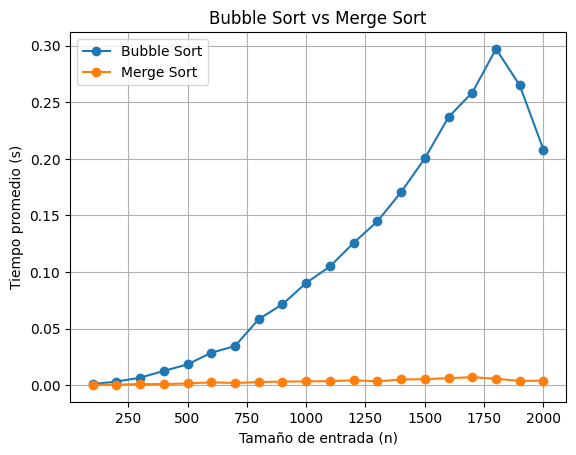

In [ ]:
ns_sort = list(range(100, 2100, 100))

tiempos_bubble = []
tiempos_merge = []

for n in ns_sort:
    datos = generar_lista_aleatoria(n)
    tiempos_bubble.append(medir_tiempo_ordenamiento(bubble_sort, datos, repeticiones=3))
    tiempos_merge.append(medir_tiempo_ordenamiento(merge_sort, datos, repeticiones=3))

plt.figure()
plt.plot(ns_sort, tiempos_bubble, marker="o", label="Bubble Sort")
plt.plot(ns_sort, tiempos_merge, marker="o", label="Merge Sort")
plt.xlabel("Tamaño de entrada (n)")
plt.ylabel("Tiempo promedio (s)")
plt.title("Bubble Sort vs Merge Sort")
plt.grid(True)
plt.legend()
plt.show()


## Interpretación esperada
A medida que `n` crece:
- Bubble Sort debería crecer más rápidamente;
- Merge Sort debería escalar mejor.


# 8. Experimento 2: curvas de referencia

Usaremos curvas de referencia escaladas:
- `n²` para Bubble Sort
- `n log n` para Merge Sort


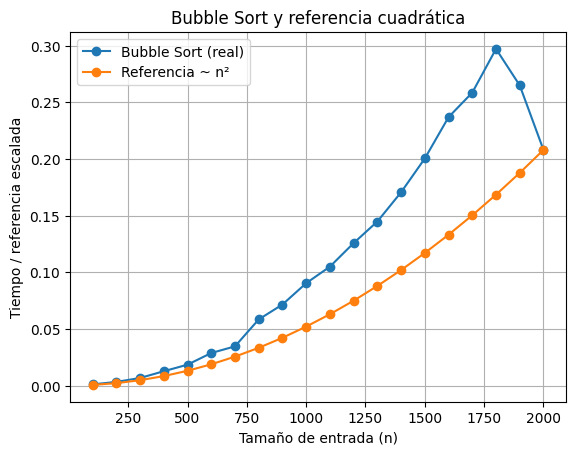

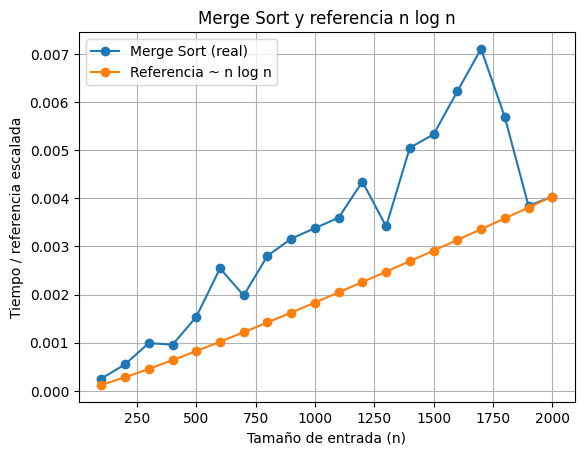

In [ ]:
ref_n2 = [n**2 for n in ns_sort]
ref_nlogn = [n * math.log2(n) for n in ns_sort]

scale_n2 = tiempos_bubble[-1] / ref_n2[-1]
scale_nlogn = tiempos_merge[-1] / ref_nlogn[-1]

ref_n2_scaled = [x * scale_n2 for x in ref_n2]
ref_nlogn_scaled = [x * scale_nlogn for x in ref_nlogn]

plt.figure()
plt.plot(ns_sort, tiempos_bubble, marker="o", label="Bubble Sort (real)")
plt.plot(ns_sort, ref_n2_scaled, marker="o", label="Referencia ~ n²")
plt.xlabel("Tamaño de entrada (n)")
plt.ylabel("Tiempo / referencia escalada")
plt.title("Bubble Sort y referencia cuadrática")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(ns_sort, tiempos_merge, marker="o", label="Merge Sort (real)")
plt.plot(ns_sort, ref_nlogn_scaled, marker="o", label="Referencia ~ n log n")
plt.xlabel("Tamaño de entrada (n)")
plt.ylabel("Tiempo / referencia escalada")
plt.title("Merge Sort y referencia n log n")
plt.grid(True)
plt.legend()
plt.show()


# 9. Experimento 3: Binary Search

Mediremos Binary Search sobre arreglos ordenados.
Como el tiempo es muy pequeño, usamos muchas repeticiones para estabilizar la medición.


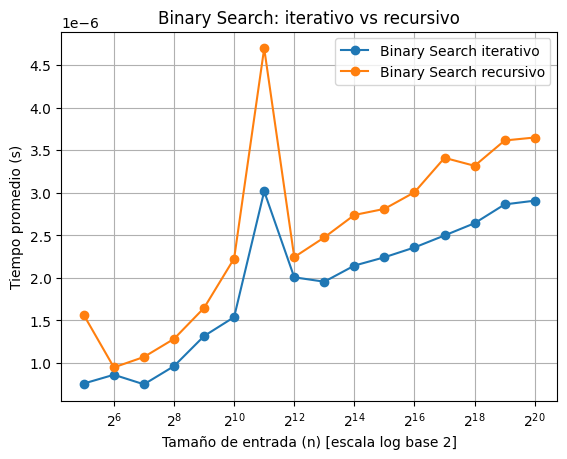

In [ ]:
ns_search = [2**k for k in range(5, 21)]  # 32 a ~1 millón

tiempos_bin_iter = []
tiempos_bin_recur = []

for n in ns_search:
    arr = list(range(n))
    target = arr[n // 2]
    tiempos_bin_iter.append(medir_tiempo_busqueda(binary_search, arr, target, repeticiones=5000))
    tiempos_bin_recur.append(medir_tiempo_busqueda(binary_search_recursive, arr, target, repeticiones=5000))

plt.figure()
plt.plot(ns_search, tiempos_bin_iter, marker="o", label="Binary Search iterativo")
plt.plot(ns_search, tiempos_bin_recur, marker="o", label="Binary Search recursivo")
plt.xscale("log", base=2)
plt.xlabel("Tamaño de entrada (n) [escala log base 2]")
plt.ylabel("Tiempo promedio (s)")
plt.title("Binary Search: iterativo vs recursivo")
plt.grid(True)
plt.legend()
plt.show()


## Observación importante
Aunque el tamaño del arreglo crece muchísimo, el tiempo de Binary Search debería aumentar muy lentamente.


# 10. Curva de referencia para Binary Search


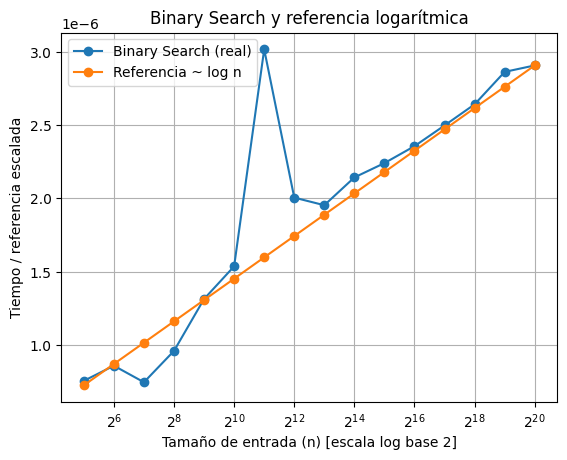

In [ ]:
ref_log = [math.log2(n) for n in ns_search]
scale_log = tiempos_bin_iter[-1] / ref_log[-1]
ref_log_scaled = [x * scale_log for x in ref_log]

plt.figure()
plt.plot(ns_search, tiempos_bin_iter, marker="o", label="Binary Search (real)")
plt.plot(ns_search, ref_log_scaled, marker="o", label="Referencia ~ log n")
plt.xscale("log", base=2)
plt.xlabel("Tamaño de entrada (n) [escala log base 2]")
plt.ylabel("Tiempo / referencia escalada")
plt.title("Binary Search y referencia logarítmica")
plt.grid(True)
plt.legend()
plt.show()


# 11. Reflexión final

## Preguntas guía
1. ¿Por qué Merge Sort sí puede analizarse con el Método Maestro y Bubble Sort no?
2. ¿Qué papel juega la etapa de combinación en Merge Sort?
3. ¿Por qué Binary Search reduce tan rápido el problema?
4. ¿Qué diferencia conceptual existe entre dividir en dos subproblemas y reducir a una sola mitad?
5. ¿Qué evidencia experimental respalda las conclusiones teóricas?

---

## Conclusión general
La estrategia de **Divide y Vencerás** permite diseñar algoritmos muy eficientes cuando la estructura del problema lo permite.

- **Merge Sort** muestra cómo dividir y combinar lleva a un crecimiento `Θ(n log n)`.
- **Binary Search** muestra cómo reducir el problema a la mitad produce crecimiento `Θ(log n)`.
- **Bubble Sort** sirve como contraste para entender cómo un algoritmo sin esta estrategia puede escalar peor.
